# LSTM Information Gain — Marginal Information Gain Experience Cache

Train an LSTM on 60% of ED patient trajectories, then compute marginal information gain (MIG)
per action block at each timestep on the held-out 40%. Following Chang et al. (ICML 2019)
"Dynamic Measurement Scheduling for Event Forecasting using Deep RL."

Key design:
- Action blocks: `vitals_checked`, `labs_ordered`, `micro_ordered`, `ecg_ordered`, `rad_ordered`, `dispense_meds`
- RL state = [h_t, action_block_mask] where h_t is the LSTM hidden state before current step's actions
- MIG = change in P(ICU transfer) when an action block's features are revealed (signed, not clipped)
- 20 random shuffles per timestep to estimate Shapley-like marginal contributions

In [1]:
!pip install -q torchmetrics huggingface_hub datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.5 MB/s eta 0:00:00a 0:00:01


In [2]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm import tqdm

pd.set_option("display.max_columns", 300)

root = "ADS599-Capstone/modeling_data"
df_patient = load_dataset(path=root, name='full_patient_state', split='full_patient_state').to_pandas()

README.md: 0.00B [00:00, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.67M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.72M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.63M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.52M [00:00<?, ?B/s]

...

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.69M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.62M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.70M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.57M [00:00<?, ?B/s]

Generating full_patient_state split:   0%|          | 0/6551723 [00:00<?, ? examples/s]

In [4]:
torch.manual_seed(10)
np.random.seed(10)
torch.cuda.manual_seed(10)
torch.cuda.manual_seed_all(10)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [5]:
# Keep only unique state rows per stay
drop_cols = df_patient.columns[4:].tolist()
drop_cols.remove("time_since_last_hrs")
drop_cols.append("ed_stay_id")
df_model = df_patient.drop_duplicates(subset=drop_cols).copy()

print(f"Original rows: {len(df_patient):,}")
print(f"Filtered rows: {len(df_model):,}")
print(f"Reduction:     {1 - len(df_model)/len(df_patient):.1%}")
print("Terminal event distribution:")
print(df_model.drop_duplicates("ed_stay_id")["terminal_event"].value_counts())

Original rows: 6,551,723
Filtered rows: 1,122,668
Reduction:     82.9%
Terminal event distribution:
terminal_event
DISCHARGE_ED      38130
DISCHARGE_WARD    27834
ICU               18247
Name: count, dtype: int64


# Preprocess and One-Hot-Encode Categorical Columns

In [6]:
# Map Gender
gender_map = {"F": 1, "M": 0}
df_model["gender_missing"] = df_model["gender"].isna().astype(int)
df_model["gender"] = df_model["gender"].map(gender_map).fillna(0)

# Change acuity to integer
df_model["acuity"] = df_model["acuity"].astype(int)

# Mask height and weight
df_model["height_missing"] = df_model["height"].isna().astype(int)
df_model["weight_missing"] = df_model["weight"].isna().astype(int)
df_model[["height", "weight"]] = df_model[["height", "weight"]].fillna(0)

# Create pain_missing column and convert the Other category to 0
df_model["pain_missing"] = (df_model["current_pain"] == "Other").astype(int)
df_model["current_pain"] = pd.to_numeric(df_model["current_pain"], errors="coerce").fillna(0)

# Mask admission type then one hot encode admission and arrival
df_model["admission_missing"] = df_model["admission_type"].isna().astype(int)
at_dummies = pd.get_dummies(df_model["admission_type"], prefix="admission_type", dummy_na=False, dtype=int)
arrival_dummies = pd.get_dummies(df_model["arrival_transport"], prefix="arrival_transport", dtype=int)
df_model_updated = pd.concat([df_model, at_dummies, arrival_dummies], axis=1).drop(columns=["admission_type", "arrival_transport"])

# One-hot encode ordinal result columns
# Lab, microbiology, ECG, and radiology columns are label-encoded integers
# that imply false ordinality. OHE removes this: 'Not_Ordered' is dropped as
# the baseline category, implied when all dummies for that column are 0.

lab_cols = [
    'Chemistry-Blood', 'Hematology-Blood', 'Hematology-Urine', 'Blood Gas-Blood',
    'Chemistry-Urine', 'Chemistry-Other Body Fluid', 'Hematology-Cerebrospinal Fluid',
    'Chemistry-Cerebrospinal Fluid', 'Hematology-Ascites', 'Chemistry-Ascites',
    'Chemistry-Pleural', 'Hematology-Pleural', 'Hematology-Joint Fluid',
    'Chemistry-Stool', 'Hematology-Other Body Fluid', 'Blood Gas-Other Body Fluid',
    'Hematology-Bone Marrow', 'Hematology-Stool', 'Chemistry-Joint Fluid', 'URINE'
]
lab_map = {0: 'Not_Ordered', 1: 'Pending', 2: 'Normal', 3: 'Abnormal'}

micro_cols = [
    'Rapid Respiratory Viral Screen & Culture', 'PERITONEAL FLUID', 'BLOOD CULTURE',
    'STOOL', 'OTHER', 'PLEURAL FLUID', 'TISSUE', 'SEROLOGY/BLOOD', 'IMMUNOLOGY',
    'MRSA SCREEN', 'SWAB', 'JOINT FLUID', 'SPUTUM', 'FLUID,OTHER', 'ABSCESS',
    'BRONCHOALVEOLAR LAVAGE', 'CSF;SPINAL FLUID', 'Blood (CMV AB)', 'Blood (EBV)', 'BILE'
]
micro_map = {0: 'Not_Ordered', 1: 'Pending', 2: 'Negative', 3: 'Positive', 4: 'Other'}

status_cols = ['ecg_status', 'rad_status']
status_map = {0: 'Not_Ordered', 1: 'Normal', 2: 'Moderate', 3: 'Acute'}

ohe_frames = [df_model_updated]

for col in lab_cols:
    mapped = df_model_updated[col].map(lab_map).fillna('Not_Ordered')
    dummies = pd.get_dummies(mapped, prefix=col, dtype=int).reindex(
        columns=[f'{col}_Pending', f'{col}_Normal', f'{col}_Abnormal'], fill_value=0)
    ohe_frames.append(dummies)

for col in micro_cols:
    mapped = df_model_updated[col].map(micro_map).fillna('Not_Ordered')
    dummies = pd.get_dummies(mapped, prefix=col, dtype=int).reindex(
        columns=[f'{col}_Pending', f'{col}_Negative', f'{col}_Positive', f'{col}_Other'], fill_value=0)
    ohe_frames.append(dummies)

for col in status_cols:
    mapped = df_model_updated[col].map(status_map).fillna('Not_Ordered')
    dummies = pd.get_dummies(mapped, prefix=col, dtype=int).reindex(
        columns=[f'{col}_Normal', f'{col}_Moderate', f'{col}_Acute'], fill_value=0)
    ohe_frames.append(dummies)

df_model_updated = pd.concat(ohe_frames, axis=1).drop(
    columns=lab_cols + micro_cols + status_cols
)
print(f'df_model_updated shape after OHE: {df_model_updated.shape}')

df_model_updated shape after OHE: (1122668, 257)


# Isolate Columns

Gender shows up as NaN so that needs to be fixed

In [7]:
# Columns out of order so this pieces all the state cols together
vitals = [c for c in df_model_updated.loc[:, 'current_temperature':'dbp_rate'].columns
          if not c.endswith('_rate') and not c.endswith('_delta')]
med_cols = [c for c in df_model_updated.columns if c.startswith('recon')]
admission_cols = at_dummies.columns.to_list() + ['admission_missing']
arrival_cols = arrival_dummies.columns.to_list()
dispensed_meds = df_model_updated.columns[4:26].to_list()

# OHE result column groups
lab_ohe_cols = [c for c in df_model_updated.columns
                if any(c.startswith(lc + '_') for lc in lab_cols)]
micro_ohe_cols = [c for c in df_model_updated.columns
                  if any(c.startswith(mc + '_') for mc in micro_cols)]
status_ohe_cols = [c for c in df_model_updated.columns
                   if any(c.startswith(sc + '_') for sc in status_cols)]

# Definitive list of patient state cols
state_cols = (
    ['gender', 'gender_missing', 'anchor_age', 'acuity', 'height', 'height_missing',
     'weight_missing', 'pain_missing', 'weight', 'in_ed', 'in_ward']
    + dispensed_meds
    + med_cols
    + vitals
    + lab_ohe_cols
    + micro_ohe_cols
    + status_ohe_cols
    + admission_cols
    + arrival_cols
)

print(f'State cols: {len(state_cols)}')

State cols: 229


In [8]:
pad_length = df_model_updated.groupby('ed_stay_id').size().max()

# Encode terminal event: discharge=0, ICU=1
terminal_event_mapping = {"DISCHARGE_WARD": 0, "DISCHARGE_ED": 0, "ICU": 1}
df_model_updated["terminal_code"] = df_model_updated["terminal_event"].map(terminal_event_mapping)

valid_stays = df_model_updated.groupby("ed_stay_id").size()
valid_stays = valid_stays[valid_stays <= pad_length].index
df_modeling = df_model_updated[df_model_updated["ed_stay_id"].isin(valid_stays)]
print(f"Stays after length filter: {df_modeling['ed_stay_id'].nunique():,}")

Stays after length filter: 84,211


In [9]:
def pad_stays(df, max_len=pad_length):
    grouped = df.groupby("ed_stay_id")
    states, labels, lengths = [], [], []

    for stay_id, group in grouped:
        s = group[state_cols].values.astype(np.float32)
        pad_len = max_len - len(s)
        s = np.pad(s, ((0, pad_len), (0, 0)))
        label = int(group["terminal_code"].iloc[0])
        states.append(s)
        labels.append(label)
        lengths.append(len(group))

    return np.stack(states), np.array(labels, dtype=np.int64), np.array(lengths)

# 60/40 Stratified Split
# Train LSTM on 60%, compute MIG on held-out 40% to avoid leakage into RL training data

In [10]:
sbs_labels = (
    df_modeling.drop_duplicates('ed_stay_id')[['ed_stay_id', 'terminal_code']]
    .reset_index(drop=True)
)

sbs_split = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=10)
sbs_train_idx, sbs_infer_idx = next(sbs_split.split(sbs_labels, sbs_labels['terminal_code']))

sbs_train_stays = set(sbs_labels.iloc[sbs_train_idx]['ed_stay_id'])
sbs_infer_stays = set(sbs_labels.iloc[sbs_infer_idx]['ed_stay_id'])

df_sbs_train = df_modeling[df_modeling['ed_stay_id'].isin(sbs_train_stays)].copy()
df_sbs_infer = df_modeling[df_modeling['ed_stay_id'].isin(sbs_infer_stays)].copy()

print(f"SbS train stays: {df_sbs_train['ed_stay_id'].nunique():,}")
print(df_sbs_train.drop_duplicates('ed_stay_id')['terminal_event'].value_counts())
print(f"\nSbS infer stays: {df_sbs_infer['ed_stay_id'].nunique():,}")
print(df_sbs_infer.drop_duplicates('ed_stay_id')['terminal_event'].value_counts())
print(f"\nOverlap: {sbs_train_stays.intersection(sbs_infer_stays)}")

SbS train stays: 50,526
terminal_event
DISCHARGE_ED      22919
DISCHARGE_WARD    16659
ICU               10948
Name: count, dtype: int64

SbS infer stays: 33,685
terminal_event
DISCHARGE_ED      15211
DISCHARGE_WARD    11175
ICU                7299
Name: count, dtype: int64

Overlap: set()


In [11]:
scaling_cols = vitals + ['anchor_age', 'weight', 'height', 'time_since_last_hrs']
sbs_scaler = StandardScaler()
df_sbs_train[scaling_cols] = sbs_scaler.fit_transform(df_sbs_train[scaling_cols])
df_sbs_infer[scaling_cols] = sbs_scaler.transform(df_sbs_infer[scaling_cols])

# Several ICU transfers were flipping to high prob of transfer once sent to ward so dropping location columns
state_cols.remove('in_ed')
state_cols.remove('in_ward')

# Started overly relying on admission columns for predictions once the location columns were removed
state_cols = [c for c in state_cols if c not in admission_cols]

# Drop columns not needed -- keep action indicator columns for the MIG pipeline
action_indicator_cols = ['observe', 'vitals_checked', 'labs_ordered', 'micro_ordered',
                         'ecg_ordered', 'rad_ordered', 'dispense_meds', 'discharge', 'transfer_icu']
keep_cols = state_cols + ['ed_stay_id', 'terminal_code', 'terminal_event', 'time', 'gender_missing'] + action_indicator_cols
extra_train = [c for c in df_sbs_train.columns if c not in keep_cols]
extra_infer = [c for c in df_sbs_infer.columns if c not in keep_cols]
df_sbs_train = df_sbs_train.drop(columns=extra_train)
df_sbs_infer = df_sbs_infer.drop(columns=extra_infer)

print(f"State cols after removals: {len(state_cols)}")
print(f"SbS train shape: {df_sbs_train.shape}")
print(f"SbS infer shape: {df_sbs_infer.shape}")
print(f"Action cols present in infer: {[c for c in action_indicator_cols if c in df_sbs_infer.columns]}")


State cols after removals: 217
SbS train shape: (674020, 230)
SbS infer shape: (448648, 230)
Action cols present in infer: ['observe', 'vitals_checked', 'labs_ordered', 'micro_ordered', 'ecg_ordered', 'rad_ordered', 'dispense_meds', 'discharge', 'transfer_icu']


In [12]:
s_sbs_train, y_sbs_train, sbs_train_len = pad_stays(df_sbs_train)
s_sbs_train = torch.tensor(s_sbs_train)
y_sbs_train = torch.tensor(y_sbs_train)
sbs_train_len = torch.tensor(sbs_train_len)

s_sbs_infer, y_sbs_infer, sbs_infer_len = pad_stays(df_sbs_infer)
s_sbs_infer = torch.tensor(s_sbs_infer)
y_sbs_infer = torch.tensor(y_sbs_infer)
sbs_infer_len = torch.tensor(sbs_infer_len)

batch_size = 16
sbs_train_loader = DataLoader(
    TensorDataset(s_sbs_train, y_sbs_train, sbs_train_len),
    batch_size=batch_size, shuffle=True,
    generator=torch.Generator().manual_seed(10),
)
sbs_infer_loader = DataLoader(
    TensorDataset(s_sbs_infer, y_sbs_infer, sbs_infer_len),
    batch_size=batch_size, shuffle=False,
)

print(f"SbS train stays: {s_sbs_train.shape[0]:,}  |  infer stays: {s_sbs_infer.shape[0]:,}")
print(f"State dim: {s_sbs_train.shape[2]}")
print(f"Train class: discharge={(y_sbs_train==0).sum():,}  icu={(y_sbs_train==1).sum():,}")
print(f"Infer class: discharge={(y_sbs_infer==0).sum():,}  icu={(y_sbs_infer==1).sum():,}")

SbS train stays: 50,526  |  infer stays: 33,685
State dim: 217
Train class: discharge=39,578  icu=10,948
Infer class: discharge=26,386  icu=7,299


# LSTM Model

In [13]:
from huggingface_hub import PyTorchModelHubMixin

input_size = len(state_cols)  # 216 after removing in_ed, in_ward, admission_cols
hidden_size = 256
num_layers = 2
dropout = 0.2
num_classes = 2  # discharge=0, ICU=1

class IgSequenceModeling(nn.Module, PyTorchModelHubMixin):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        return self.fc(h_n[-1])  # (B, num_classes) — raw logits

ig_model = IgSequenceModeling().to(device)

# Class weight for ICU minority class
sbs_n_discharge = (y_sbs_train == 0).sum().float()
sbs_n_icu = (y_sbs_train == 1).sum().float()
sbs_class_weight = torch.tensor([1.0, (sbs_n_discharge / sbs_n_icu).item()]).to(device)
sbs_loss_fn = nn.CrossEntropyLoss(weight=sbs_class_weight)
sbs_optimizer = torch.optim.AdamW(ig_model.parameters(), lr=1e-4)

print(f"input_size: {input_size}")
print(f"Class weights: discharge={sbs_class_weight[0]:.2f}  icu={sbs_class_weight[1]:.2f}")
print(ig_model)

input_size: 217
Class weights: discharge=1.00  icu=3.62
IgSequenceModeling(
  (lstm): LSTM(217, 256, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


In [14]:
from torchmetrics.classification import MulticlassF1Score
f1 = MulticlassF1Score(num_classes=num_classes, average="macro")
f1_per_class = MulticlassF1Score(num_classes=num_classes, average="none")

def training_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0
    for batch, (X, y, lengths) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(X, lengths)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        if batch % 500 == 0:
            current = batch * batch_size + len(X)
            print(f"loss: {loss.item():>7.4f} [{current:>5d}/{size:>5d}]")
    return total_loss / len(dataloader)

def evaluation_loop(dataloader, model, loss_fn):
    num_batches = len(dataloader)
    test_loss = 0
    preds, true_y = [], []
    model.eval()
    with torch.no_grad():
        for X, y, lengths in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X, lengths)
            test_loss += loss_fn(pred, y).item()
            preds.append(torch.softmax(pred, dim=-1).cpu())
            true_y.append(y.cpu())
    final_preds = torch.cat(preds, dim=0)
    true_labels = torch.cat(true_y, dim=0)
    test_loss /= num_batches
    f1_macro = f1(final_preds, true_labels).item()
    f1_per = f1_per_class(final_preds, true_labels)
    print(f"\nAvg Loss: {test_loss:.4f}  F1_Macro: {f1_macro:.4f}")
    for cls, score in zip(["discharge", "icu"], f1_per.tolist()):
        print(f"  {cls}: {score:.4f}")
    return final_preds, true_labels, test_loss


Epoch 1------------------------------
loss:  0.6830 [   16/50526]
loss:  0.3241 [ 8016/50526]
loss:  0.1391 [16016/50526]
loss:  0.3395 [24016/50526]
loss:  0.2993 [32016/50526]
loss:  0.6304 [40016/50526]
loss:  0.3913 [48016/50526]

Avg Loss: 0.3016  F1_Macro: 0.8307
  discharge: 0.9166
  icu: 0.7448
  ** New best: 0.3016

Epoch 2------------------------------
loss:  0.2128 [   16/50526]
loss:  0.3673 [ 8016/50526]
loss:  0.1228 [16016/50526]
loss:  0.2729 [24016/50526]
loss:  0.3492 [32016/50526]
loss:  0.2688 [40016/50526]
loss:  0.1905 [48016/50526]

Avg Loss: 0.2788  F1_Macro: 0.8429
  discharge: 0.9224
  icu: 0.7634
  ** New best: 0.2788

Epoch 3------------------------------
loss:  0.3873 [   16/50526]
loss:  0.1032 [ 8016/50526]
loss:  0.1629 [16016/50526]
loss:  0.8648 [24016/50526]
loss:  0.0856 [32016/50526]
loss:  0.0993 [40016/50526]
loss:  0.1905 [48016/50526]

Avg Loss: 0.2869  F1_Macro: 0.8615
  discharge: 0.9362
  icu: 0.7867
  No improvement 1/3

Epoch 4------------

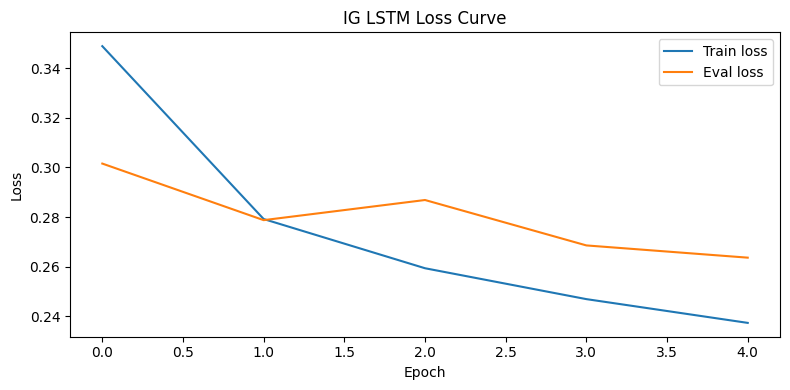

In [15]:
import os, tempfile
from huggingface_hub import HfApi

epochs = 5
sbs_patience = 3
sbs_best_loss = float('inf')
sbs_no_improve = 0
sbs_best_state = None
sbs_best_epoch = 0
sbs_train_losses = []
sbs_eval_losses = []

hf_api = HfApi()

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}------------------------------")
    t_loss = training_loop(sbs_train_loader, ig_model, sbs_loss_fn, sbs_optimizer)
    sbs_train_losses.append(t_loss)
    _, _, e_loss = evaluation_loop(sbs_infer_loader, ig_model, sbs_loss_fn)
    sbs_eval_losses.append(e_loss)

    if e_loss < sbs_best_loss:
        sbs_best_loss = e_loss
        sbs_best_epoch = epoch + 1
        sbs_best_state = {k: v.clone() for k, v in ig_model.state_dict().items()}
        sbs_no_improve = 0
        print(f"  ** New best: {sbs_best_loss:.4f}")
    else:
        sbs_no_improve += 1
        print(f"  No improvement {sbs_no_improve}/{sbs_patience}")
        if sbs_no_improve >= sbs_patience:
            print(f"Early stopping at epoch {epoch + 1}. Best epoch: {sbs_best_epoch}")
            break

ig_model.load_state_dict(sbs_best_state)
print(f"\nRestored IG LSTM model from epoch {sbs_best_epoch} (loss: {sbs_best_loss:.4f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sbs_train_losses, label='Train loss')
ax.plot(sbs_eval_losses, label='Eval loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('IG LSTM Loss Curve')
ax.legend()
plt.tight_layout()
plt.show()

# Save Model Weights to HuggingFace

In [16]:
model_repo = 'ADS599-Capstone/information_gain_lstm'
hf_api.create_repo(model_repo, exist_ok=True, private=True)

with tempfile.NamedTemporaryFile(suffix='.pt', delete=False) as tmp:
    tmp_path = tmp.name
    torch.save(ig_model.state_dict(), tmp.name)

hf_api.upload_file(
    path_or_fileobj=tmp_path,
    path_in_repo='ig_lstm_best.pt',
    repo_id=model_repo,
)
os.unlink(tmp_path)
print(f"Model saved to {model_repo}/ig_lstm_best.pt")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /tmp/tmpk9mlcs7q.pt         :  97%|#########6| 3.92MB / 4.06MB            

Model saved to ADS599-Capstone/information_gain_lstm/ig_lstm_best.pt


## Load Back

In [17]:
from huggingface_hub import hf_hub_download

path = hf_hub_download(repo_id='ADS599-Capstone/information_gain_lstm', filename='ig_lstm_best.pt')
ig_model.load_state_dict(torch.load(path, map_location=device))

ig_lstm_best.pt:   0%|          | 0.00/4.06M [00:00<?, ?B/s]

<All keys matched successfully>

# Experience Caching Pipeline

Marginal Information Gain (MIG) is computed per action block per timestep following Chang et al. (ICML 2019).

For each patient trajectory on the held-out 40%:
1. Run one sequential LSTM pass to pre-compute prefix hidden states `(h_{t-1}, c_{t-1})` at each timestep
2. At each timestep where intermediate actions were taken:
   - Mask all action-block features → run one LSTM step → baseline probability `p₀`
   - For each of 20 random shuffles of the action blocks taken:
     - Reveal action blocks one at a time
     - Run one LSTM step forward from the cached prefix state after each reveal
     - `marginal_ig = p_new - p_prev` (signed, not clipped)
     - Store experience tuple

RL state = `[h_t, action_block_mask]` where `h_t` is the LSTM hidden state before this timestep's actions.
MIG is computed on `P(ICU transfer)` — the transfer class probability specifically.

In [18]:
TERMINAL_ACTIONS = ['discharge', 'transfer_icu']
INTERMEDIATE_ACTIONS = ['observe', 'vitals_checked', 'labs_ordered', 'micro_ordered',
                        'ecg_ordered', 'rad_ordered', 'dispense_meds']

# Vitals block — same slice logic as lstm_one_hot_modeling.ipynb
vitals_block = [c for c in vitals if c in state_cols]

# Lab block — OHE of 20 lab types x 3 statuses (Pending, Normal, Abnormal; Not_Ordered dropped)
lab_statuses = ['Pending', 'Normal', 'Abnormal']
labs_block = [f"{lab}_{status}" for lab in lab_cols for status in lab_statuses
              if f"{lab}_{status}" in state_cols]

# Culture/micro block — OHE of 20 culture types x 4 statuses (Pending, Negative, Positive, Other)
micro_statuses = ['Pending', 'Negative', 'Positive', 'Other']
micro_block = [f"{culture}_{status}" for culture in micro_cols for status in micro_statuses
               if f"{culture}_{status}" in state_cols]

# ECG and radiology blocks
ecg_block = [c for c in state_cols if c.startswith('ecg_status_')]
rad_block = [c for c in state_cols if c.startswith('rad_status_')]

# Medication block — ED-dispensed medications only (recon_ prefix = pre-ED static meds, excluded)
dispense_med_names = [
    'Other', 'Analgesic - Opioid/NSAID', 'Antiemetic', 'Analgesic - Acetaminophen',
    'Antibiotic', 'Benzodiazepine - Sedative/Anxiolytic', 'Analgesic - NSAID',
    'Bronchodilator', 'Antiplatelet', 'GI - Acid Suppression', 'Corticosteroid',
    'Beta Blocker', 'Diuretic', 'Antipsychotic', 'Anticoagulant', 'Insulin/Glucose',
    'Calcium Channel Blocker', 'Nitrate', 'ACE Inhibitor', 'IV Fluid',
    'Anticonvulsant', 'Antiarrhythmic'
]
# Handle both plain names and dispense_ prefix
meds_block = [c for c in state_cols
              if c in dispense_med_names or c in [f'dispense_{m}' for m in dispense_med_names]]

ACTION_BLOCKS = {
    'vitals_checked': vitals_block,
    'labs_ordered': labs_block,
    'micro_ordered': micro_block,
    'ecg_ordered': ecg_block,
    'rad_ordered': rad_block,
    'dispense_meds': meds_block,
    'observe': [],  # no features — observe rows skipped in cache
}

for action, cols in ACTION_BLOCKS.items():
    print(f"{action}: {len(cols)} columns")

# Sanity check: all block cols must be in state_cols
for action, cols in ACTION_BLOCKS.items():
    missing = [c for c in cols if c not in state_cols]
    if missing:
        print(f"WARNING — {action} has {len(missing)} missing cols: {missing[:3]}")

vitals_checked: 16 columns
labs_ordered: 60 columns
micro_ordered: 80 columns
ecg_ordered: 3 columns
rad_ordered: 3 columns
dispense_meds: 22 columns
observe: 0 columns


In [19]:
class HiddenStateExtractor(nn.Module):
    """Wraps IgSequenceModeling to expose the LSTM hidden state alongside logits.

    Used during experience caching only — never during training.
    The LSTM weights are shared with ig_model (same tensor references),
    so this wrapper must not be serialized with safetensors.
    """
    def __init__(self, lstm_model):
        super().__init__()
        self.lstm = lstm_model.lstm
        self.fc = lstm_model.fc

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        h_last = h_n[-1]  # (B, hidden_size) top layer
        logits = self.fc(h_last)
        return logits, h_last

ig_extractor = HiddenStateExtractor(ig_model).to(device)
ig_extractor.eval()
print("HiddenStateExtractor ready (eval mode)")

HiddenStateExtractor ready (eval mode)


In [20]:
# Use the sbs infer split (held-out 40%) — model has never seen these stays
# df_sbs_infer already has scaling applied; sort by stay then timestep
df_infer = df_sbs_infer.sort_values(['ed_stay_id', 'time']).copy()

# MASKABLE_ACTIONS: intermediate actions that have associated feature blocks
# 'observe' is excluded — no features to mask, observe rows are skipped in the cache
MASKABLE_ACTIONS = ['vitals_checked', 'labs_ordered', 'micro_ordered',
                    'ecg_ordered', 'rad_ordered', 'dispense_meds']
mask_dim = len(MASKABLE_ACTIONS)

print(f"Infer stays: {df_infer['ed_stay_id'].nunique():,}")
print(f"Infer rows:  {len(df_infer):,}")
print(f"Mask dim (action_block_mask): {mask_dim}")

Infer stays: 33,685
Infer rows:  448,648
Mask dim (action_block_mask): 6


In [21]:
print(df_infer.value_counts('transfer_icu'))
print("\n", df_infer.value_counts('discharge'))

transfer_icu
0    441349
1      7299
Name: count, dtype: int64

 discharge
0    422262
1     26386
Name: count, dtype: int64


In [ ]:
df_infer[df_infer['ed_stay_id'] == 30000177]

In [22]:
from itertools import permutations
from tqdm import tqdm

experiences = []
state_col_idx = {col: i for i, col in enumerate(state_cols)}  # fast column -> index lookup

ig_extractor.eval()

for stay_id, stay_df in tqdm(df_infer.groupby("ed_stay_id"), total=df_infer["ed_stay_id"].nunique(), desc="Caching MIG"):
    stay_df = stay_df.reset_index(drop=True)

    seq = torch.tensor(stay_df[state_cols].values.astype(np.float32), device=device)
    T = len(seq)

    # --- Pass 1: pre-compute prefix hidden states (h_{t-1}, c_{t-1}) for each t ---
    # h after the loop = h_T (hidden state after all T steps), used for the terminal row
    prefix_h = []
    h = torch.zeros(num_layers, 1, hidden_size, device=device)
    c = torch.zeros(num_layers, 1, hidden_size, device=device)
    with torch.no_grad():
        for t in range(T):
            prefix_h.append((h.clone(), c.clone()))
            x_t = seq[t].unsqueeze(0).unsqueeze(0)
            _, (h, c) = ig_extractor.lstm(x_t, (h, c))

    # --- Pass 2: compute MIG per timestep ---
    for t in range(T):
        row = stay_df.iloc[t]
        actions_taken = [a for a in MASKABLE_ACTIONS if row.get(a, 0) == 1]
        if not actions_taken:
            continue  # observe-only timestep - skip

        h_prefix, c_prefix = prefix_h[t]
        h_t_vec = h_prefix[-1].squeeze(0).cpu().numpy()  # (hidden_size,)

        # Baseline: zero out all action-block features for this step -> one LSTM step -> p0
        row_masked = seq[t].clone()
        for a in actions_taken:
            for col in ACTION_BLOCKS[a]:
                row_masked[state_col_idx[col]] = 0.0

        with torch.no_grad():
            _, (h_base, _) = ig_extractor.lstm(
                row_masked.unsqueeze(0).unsqueeze(0), (h_prefix, c_prefix)
            )
            p0 = torch.softmax(ig_extractor.fc(h_base[-1].squeeze(0)), dim=-1)[1].item()

            _, (h_final, _) = ig_extractor.lstm(
                seq[t].unsqueeze(0).unsqueeze(0), (h_prefix, c_prefix)
            )
            p_final = torch.softmax(ig_extractor.fc(h_final[-1].squeeze(0)), dim=-1)[1].item()

        for shuffle_id, order in enumerate(permutations(actions_taken)):
            current_row = row_masked.clone()
            p_prev = p0
            action_block_mask = np.zeros(mask_dim, dtype=np.float32)

            for action in order:
                for col in ACTION_BLOCKS[action]:
                    current_row[state_col_idx[col]] = seq[t, state_col_idx[col]]

                action_block_mask[MASKABLE_ACTIONS.index(action)] = 1.0

                with torch.no_grad():
                    _, (h_run, _) = ig_extractor.lstm(
                        current_row.unsqueeze(0).unsqueeze(0), (h_prefix, c_prefix)
                    )
                    p_new = torch.softmax(ig_extractor.fc(h_run[-1].squeeze(0)), dim=-1)[1].item()

                experiences.append({
                    "ed_stay_id": stay_id,
                    "timestep": int(t),
                    "action": action,
                    "marginal_ig": float(p_new - p_prev),
                    "shuffle_id": int(shuffle_id),
                    "hidden_state": h_t_vec.tolist(),
                    "action_block_mask": action_block_mask.tolist(),
                    "baseline_prob": float(p0),
                    "final_prob": float(p_final),
                })
                p_prev = p_new

    # --- Terminal row: h_T is h after Pass 1 completes (no extra forward pass needed) ---
    terminal_row = stay_df.iloc[-1]
    h_T_vec = h[-1].squeeze(0).cpu().numpy()

    experiences.append({
        "ed_stay_id": stay_id,
        "timestep": T - 1,
        "action": "discharge" if terminal_row["terminal_code"] == 0 else "transfer_icu",
        "marginal_ig": None,
        "shuffle_id": -1,
        "hidden_state": h_T_vec.tolist(),
        "action_block_mask": [0.0] * mask_dim,
        "baseline_prob": None,
        "final_prob": None,
        "discharge": int(terminal_row["discharge"]),
        "transfer_icu": int(terminal_row["transfer_icu"]),
    })

df_cache = pd.DataFrame(experiences)

# Merge terminal_code as a stay-level label onto all rows
stay_terminal = df_cache[df_cache["shuffle_id"] == -1][["ed_stay_id", "action"]].copy()
stay_terminal["terminal_code"] = stay_terminal["action"].map({"discharge": 0, "transfer_icu": 1})
stay_terminal = stay_terminal[["ed_stay_id", "terminal_code"]]
df_cache = df_cache.merge(stay_terminal, on="ed_stay_id", how="left")

print(f"Total experience tuples: {len(df_cache):,}")
print(f"  MIG tuples:      {(df_cache["shuffle_id"] >= 0).sum():,}")
print(f"  Terminal tuples: {(df_cache["shuffle_id"] == -1).sum():,}")
print(df_cache[["ed_stay_id", "timestep", "action", "marginal_ig", "shuffle_id", "terminal_code"]].head(20))


Caching MIG: 100%|██████████| 33685/33685 [25:03<00:00, 22.40it/s]  


Total experience tuples: 791,337
  MIG tuples:      757,652
  Terminal tuples: 33,685
    ed_stay_id  timestep          action  marginal_ig  shuffle_id  \
0     30000177         0  vitals_checked     0.022833           0   
1     30000177         0    labs_ordered     0.475424           0   
2     30000177         0    labs_ordered     0.510988           1   
3     30000177         0  vitals_checked    -0.012731           1   
4     30000177         1    labs_ordered     0.198101           0   
5     30000177         2   dispense_meds     0.000068           0   
6     30000177         6  vitals_checked     0.014915           0   
7     30000177         9    labs_ordered     0.303077           0   
8     30000177        10    labs_ordered     0.390062           0   
9     30000177        13    labs_ordered     0.205248           0   
10    30000177        14       discharge          NaN          -1   
11    30000275         0  vitals_checked     0.028042           0   
12    30000275   

In [23]:
# Cache diagnostics
print("MIG distribution:")
print(df_cache['marginal_ig'].describe())
print(f"\nAction distribution:")
print(df_cache['action'].value_counts())
print(f"\nObserve rows in cache (should be 0): {(df_cache['action'] == 'observe').sum()}")
print(f"Expected tuples ≈ (non-observe timesteps) × {3} × (avg actions per timestep)")
print(f"\nSample — p_final vs baseline_prob:")
print(df_cache[['ed_stay_id', 'timestep', 'baseline_prob', 'final_prob']].drop_duplicates(['ed_stay_id', 'timestep']).head(10))

MIG distribution:
count    757652.000000
mean          0.092855
std           0.172279
min          -0.487223
25%           0.000112
50%           0.013951
75%           0.101108
max           0.993878
Name: marginal_ig, dtype: float64

Action distribution:
action
vitals_checked    248462
labs_ordered      198868
dispense_meds     127269
rad_ordered        71900
ecg_ordered        63897
micro_ordered      47256
discharge          26386
transfer_icu        7299
Name: count, dtype: int64

Observe rows in cache (should be 0): 0
Expected tuples ≈ (non-observe timesteps) × 3 × (avg actions per timestep)

Sample — p_final vs baseline_prob:
    ed_stay_id  timestep  baseline_prob  final_prob
0     30000177         0       0.350738    0.848996
4     30000177         1       0.800112    0.998214
5     30000177         2       0.999885    0.999953
6     30000177         6       0.956786    0.971700
7     30000177         9       0.154849    0.457927
8     30000177        10       0.114668    0.5

# Save Experience Cache to HuggingFace

In [24]:
from datasets import Dataset

data_repo = 'ADS599-Capstone/information_gain_cache'
# hf_api.create_repo(data_repo, repo_type="dataset", exist_ok=True, private=True)

# Save locally as Parquet first
# cache_path = 'data/ig_experience_cache.parquet'
# df_cache.to_parquet(cache_path, index=False)
# print(f"Saved locally to {cache_path}")

# Push to HuggingFace
hf_dataset = Dataset.from_pandas(df_cache.reset_index(drop=True))
hf_dataset.push_to_hub(data_repo, split='train')
print(f"Pushed {len(df_cache):,} rows to {data_repo}")
print(f"  Unique stays: {df_cache['ed_stay_id'].nunique():,}")
print(f"  Columns: {df_cache.shape[1]}")
print(df_cache.dtypes)

Uploading the dataset shards:   0%|          | 0/4 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/198 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :   4%|3         | 6.44MB /  165MB            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :   3%|2         | 4.49MB /  164MB            

README.md:   0%|          | 0.00/731 [00:00<?, ?B/s]

Pushed 791,337 rows to ADS599-Capstone/information_gain_cache
  Unique stays: 33,685
  Columns: 12
ed_stay_id             int64
timestep               int64
action                object
marginal_ig          float64
shuffle_id             int64
hidden_state          object
action_block_mask     object
baseline_prob        float64
final_prob           float64
discharge            float64
transfer_icu         float64
terminal_code          int64
dtype: object
